# 3D DSM Solver for Mixed Truss-Frame Structures

This project implements a 3D Direct Stiffness Method (DSM) solver.

In [ ]:
import numpy as np
import json
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### DSM

F_fef_global =
[    0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0.             0.
     0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0.             0.
     0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0.             0.
     0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0.             0.
     0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0.             0.
     0.          -140.             0.           326.66666667
     0.             0.             0.             0.
     0.             0.             0

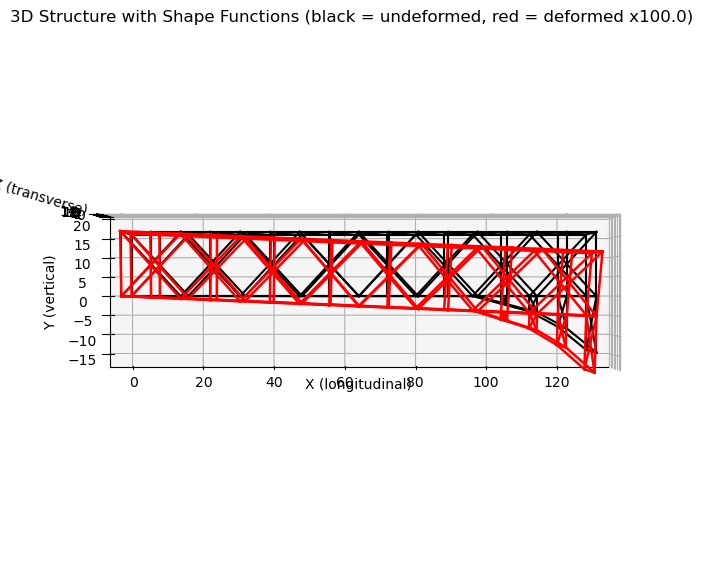

Deformed shape png written to: outputs\final_structure_no_tem\final_structure_no_tem_deformed.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from helpers.preprocess import (
    read_model_json,
    normalize_model_data,
    parse_elements,
    get_single_material,
    build_global_nodal_load_vector,
    build_restrained_dofs_1based,
    build_prescribed_displacement_vector,
)
from helpers.geometry3d import build_elements_RL
from helpers.truss3d import (
    truss_element_kl_3d,
    truss_element_Qf_3d,
    truss_element_T_3d,
    truss_element_Qf_temp_3d,
    truss_element_Qf_fabrication_3d
)

from helpers.frame3d import (
    frame_element_kl_3d,
    frame_element_Qf_3d,
    frame_element_T_3d,
    frame_element_Qf_temp_3d,
    frame_element_Qf_fabrication_3d,
)
from helpers.assembly import (
    element_dof_map_3d_1based,
    assemble_global_stiffness_and_fef,
)
from helpers.solver import solve_linear_static
from helpers.postprocess import (
    print_dsm_results,
    print_element_truss3d,
    print_element_frame3d,
    plot_structure_3d,
    plot_structure_3d_shape_functions,
    plot_structure_3d_shape_functions_interactive,
    write_results_txt,
)



def apply_release_to_k_local_3d(k_local, rel):
    """
    Apply member end releases by static condensation.

    Released DOFs are internally condensed out instead of being set to
    near-zero stiffness. This avoids artificial mechanisms caused by
    k[idx, idx] = 1e-12.
    """
    dof_map = {
        ("i", "ux"): 0, ("i", "uy"): 1, ("i", "uz"): 2,
        ("i", "rx"): 3, ("i", "ry"): 4, ("i", "rz"): 5,
        ("j", "ux"): 6, ("j", "uy"): 7, ("j", "uz"): 8,
        ("j", "rx"): 9, ("j", "ry"): 10, ("j", "rz"): 11,
    }

    released = []
    for side in ["i", "j"]:
        for dof_name in rel.get(side, []):
            released.append(dof_map[(side, dof_name)])

    released = sorted(set(released))

    if not released:
        return k_local.copy()

    all_dofs = list(range(12))
    kept = [d for d in all_dofs if d not in released]

    k = k_local.copy()

    Kaa = k[np.ix_(kept, kept)]
    Kab = k[np.ix_(kept, released)]
    Kba = k[np.ix_(released, kept)]
    Kbb = k[np.ix_(released, released)]

    # Static condensation:
    # K_cond = Kaa - Kab @ inv(Kbb) @ Kba
    Kbb_inv = np.linalg.pinv(Kbb)
    K_cond = Kaa - Kab @ Kbb_inv @ Kba

    k_mod = np.zeros_like(k_local)
    k_mod[np.ix_(kept, kept)] = K_cond

# give released DOFs a tiny numerical stiffness to avoid singular global K
    diag_ref = np.max(np.abs(np.diag(k_local)))
    if diag_ref <= 0:
         diag_ref = 1.0

    for d in released:
        k_mod[d, d] = diag_ref * 1e-6

    return k_mod


def apply_release_to_qf_local_3d(Qf_local, k_local_original, rel):
    """
    Condense fixed-end force vector consistently with released DOFs.
    """
    dof_map = {
        ("i", "ux"): 0, ("i", "uy"): 1, ("i", "uz"): 2,
        ("i", "rx"): 3, ("i", "ry"): 4, ("i", "rz"): 5,
        ("j", "ux"): 6, ("j", "uy"): 7, ("j", "uz"): 8,
        ("j", "rx"): 9, ("j", "ry"): 10, ("j", "rz"): 11,
    }

    released = []
    for side in ["i", "j"]:
        for dof_name in rel.get(side, []):
            released.append(dof_map[(side, dof_name)])

    released = sorted(set(released))

    if not released:
        return Qf_local.copy()

    all_dofs = list(range(12))
    kept = [d for d in all_dofs if d not in released]

    k = k_local_original.copy()
    q = Qf_local.copy()

    Kab = k[np.ix_(kept, released)]
    Kbb = k[np.ix_(released, released)]

    qa = q[kept]
    qb = q[released]

    Kbb_inv = np.linalg.pinv(Kbb)

    # Consistent condensation of fixed-end force vector
    q_cond = qa - Kab @ Kbb_inv @ qb

    q_mod = np.zeros_like(Qf_local)
    q_mod[kept] = q_cond

    return q_mod

def build_element_matrices(
    nodes,
    elements,
    materials,
    sections,
    member_loads,
    releases,
    temperature_loads,
    fabrication_errors,
    planar_frame_xy=False,
):
    """
    Build:
        k_list
        T_list
        Qf_list
        map_list
        meta_list
    """
    material = get_single_material(materials)

    E = float(material["E"])
    nu = float(material.get("nu", 0.30))
    G = float(material.get("G", E / (2.0 * (1.0 + nu))))
    alpha_default = float(material.get("alpha", 1.2e-5))

    temp_all = temperature_loads.get("all", {})
    deltaT_all = float(temp_all.get("deltaT", 0.0))
    alpha_all = float(temp_all.get("alpha", alpha_default))

    elements_RL = build_elements_RL(
        elements,
        nodes,
        planar_frame_xy=planar_frame_xy,
    )

    k_list = []
    T_list = []
    Qf_list = []
    map_list = []
    meta_list = []

    for e_id in sorted(elements.keys()):
        e_data = elements[e_id]

        i, j = e_data["nodes"]
        sec_name = e_data["section"]
        etype = e_data["type"]

        sec = sections[sec_name]

        R = elements_RL[e_id]["R"]
        L = elements_RL[e_id]["L"]

        m_1based = element_dof_map_3d_1based(i, j)

        temp_e = temperature_loads.get(str(e_id), temperature_loads.get(e_id, temp_all))
        deltaT = float(temp_e.get("deltaT", deltaT_all))
        alpha = float(temp_e.get("alpha", alpha_all))

        fab_e = fabrication_errors.get(str(e_id), fabrication_errors.get(e_id, {}))
        deltaL = float(fab_e.get("deltaL", 0.0))

        # ------------------------------------------------------------
        # Truss element
        # ------------------------------------------------------------
        if etype == "truss":
            A = float(sec["A"])

            k_local = truss_element_kl_3d(E, A, L)
            T = truss_element_T_3d(R)
            Qf_local = truss_element_Qf_3d()

            if deltaT != 0.0:
                Qf_local = Qf_local + truss_element_Qf_temp_3d(
                    E,
                    A,
                    alpha,
                    deltaT,
                )

            if deltaL != 0.0:
                Qf_local = Qf_local + truss_element_Qf_fabrication_3d(
                    E,
                    A,
                    L,
                    deltaL,
                )

        # ------------------------------------------------------------
        # Frame element
        # ------------------------------------------------------------
        elif etype == "frame":
            A = float(sec["A"])
            Iy = float(sec["Iy"])
            Iz = float(sec["Iz"])
            J = float(sec["J"])

            k_local = frame_element_kl_3d(E, G, A, Iy, Iz, J, L)
            T = frame_element_T_3d(R)

            e_loads = member_loads.get(e_id, member_loads.get(str(e_id), []))
            Qf_local = frame_element_Qf_3d(L, e_loads)

            if deltaT != 0.0:
                Qf_local = Qf_local + frame_element_Qf_temp_3d(
                    E,
                    A,
                    alpha,
                    deltaT,
                )

            if deltaL != 0.0:
                Qf_local = Qf_local + frame_element_Qf_fabrication_3d(
                    E,
                    A,
                    L,
                    deltaL,
                )

        else:
            raise ValueError(f"Unknown element type {etype} in element {e_id}.")

        # ------------------------------------------------------------
        # Apply member end releases
        # ------------------------------------------------------------
        rel = releases.get(e_id, releases.get(str(e_id), {}))

        if rel:
               k_local_original = k_local.copy()
               Qf_local = apply_release_to_qf_local_3d(Qf_local, k_local_original, rel)
               k_local = apply_release_to_k_local_3d(k_local_original, rel)

        # ------------------------------------------------------------
        # Store element data
        # ------------------------------------------------------------
        k_list.append(k_local)
        T_list.append(T)
        Qf_list.append(Qf_local)
        map_list.append(m_1based)

        meta_list.append(
            {
                "e_id": e_id,
                "type": etype,
                "section": sec_name,
                "nodes": [i, j],
                "L": L,
            }
        )

    return k_list, T_list, Qf_list, map_list, meta_list

def main(json_path):
    # ------------------------------------------------------------
    # 1) Read and normalize model
    # ------------------------------------------------------------
    data = read_model_json(json_path)
    model = normalize_model_data(data)

    nodes = model["nodes"]
    materials = model["materials"]
    sections = model["sections"]
    elements = parse_elements(model["elements"])
    nodes_restrained = model["nodes_restrained"]
    nodal_loads = model["nodal_loads"]
    nodes_prescribed = model["nodes_prescribed"]
    member_loads = model.get("member_loads", {})
    releases = model.get("releases", {})
    temperature_loads = model.get("temperature_loads", {})
    fabrication_errors = model.get("fabrication_errors", {})

    n_nodes = len(nodes)
    ndof = 6 * n_nodes

    # ------------------------------------------------------------
    # 2) Global loads / prescribed displacements / restraints
    # ------------------------------------------------------------
    F_global = build_global_nodal_load_vector(nodes, nodal_loads)
    u_global = build_prescribed_displacement_vector(nodes, nodes_prescribed)
    dof_restrained_1based = build_restrained_dofs_1based(nodes_restrained)

    # ------------------------------------------------------------
    # 3) Element routines
    # ------------------------------------------------------------
    k_list, T_list, Qf_list, map_list, meta_list = build_element_matrices(
    nodes, elements, materials, sections,
    member_loads, releases, temperature_loads, fabrication_errors,
    planar_frame_xy= False
)
    

    # ------------------------------------------------------------
    # 4) Assembly
    # ------------------------------------------------------------
    K_global, F_fef_global = assemble_global_stiffness_and_fef(
        ndof,
        k_list,
        T_list,
        Qf_list,
        map_list,
    )
    print("F_fef_global =")
    print(F_fef_global)
    # ------------------------------------------------------------
    # 5) Solve
    # ------------------------------------------------------------
    sol = solve_linear_static(
        K_global,
        F_global,
        u_global,
        F_fef_global,
        dof_restrained_1based,
    )

    u_global = sol["u_global"]
    f_global_complete = sol["f_global_complete"]

        # ------------------------------------------------------------
    # 6) Results
    # ------------------------------------------------------------
    print("\n=== GLOBAL RESULTS ===")
    print_dsm_results(
        u_global,
        f_global_complete,
        dof_restrained_1based,
        disp_in_mm=True,
    )

    print("\n=== ELEMENT RESULTS ===")
    for meta, k_local, T, Qf_local, m_1based in zip(
        meta_list, k_list, T_list, Qf_list, map_list
    ):
        if meta["type"] == "truss":
            print_element_truss3d(
                meta["e_id"],
                u_global,
                m_1based,
                T,
                k_local,
                Qf_local=Qf_local,
                disp_in_mm=True,
                dec=3,
            )
        else:
            print_element_frame3d(
                meta["e_id"],
                u_global,
                m_1based,
                T,
                k_local,
                Qf_local,
                disp_in_mm=True,
                dec=3,
                rad_dec=6,
            )

    # ------------------------------------------------------------
    # 6.5) Save txt summary into outputs/<case_name>/
    # ------------------------------------------------------------
    import os

    case_name = os.path.splitext(os.path.basename(json_path))[0]
    case_out_dir = os.path.join("outputs", case_name)
    os.makedirs(case_out_dir, exist_ok=True)

    txt_path = os.path.join(case_out_dir, f"{case_name}_summary.txt")

    write_results_txt(
        out_path=txt_path,
        u_global=u_global,
        f_global_complete=f_global_complete,
        dof_restrained_1based=dof_restrained_1based,
        meta_list=meta_list,
        k_list=k_list,
        T_list=T_list,
        Qf_list=Qf_list,
        map_list=map_list,
        disp_in_mm=True,
        dec=3,
        rad_dec=6,
    )

    print(f"\nSummary txt written to: {txt_path}")

    # ------------------------------------------------------------
    # 7) Plot
    # ------------------------------------------------------------
    deformed_png_path = os.path.join(case_out_dir, f"{case_name}_deformed.png")

    plot_structure_3d_shape_functions(
        nodes,
        elements,
        u_global,
        T_list,
        map_list,
        meta_list,
        scale=100.0,
        npts=41,
        save_path=deformed_png_path,
    )

    print(f"Deformed shape png written to: {deformed_png_path}")

    plot_structure_3d_shape_functions_interactive(
        nodes,
        elements,
        u_global,
        T_list,
        map_list,
        meta_list,
        scale=100.0,
        npts=41,
        show_node_ids=False,
    )


if __name__ == "__main__": 
    # chooce the structure below to run the DSM
    
    # final complex structure
    # main(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\final_structure.json")
    main(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\final_structure_no_tem.json")

    # open 2D validation: should firstly set: planar_frame_xy= True 
    # validation_truss
    # main(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\validation_truss.json")
    
    # validation_frame_baseline
    # main(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\validation_frame_baseline.json")
    
    # validation_frame_support_settlement
    # main(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\validation_frame_support_settlement.json")
    
    # validation_frame_fabrication_error
    # main (r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\validation_frame_fabrication_error.json")
    
    # validation_frame_release_error
    # main (r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\validation_frame_release.json")
    pass


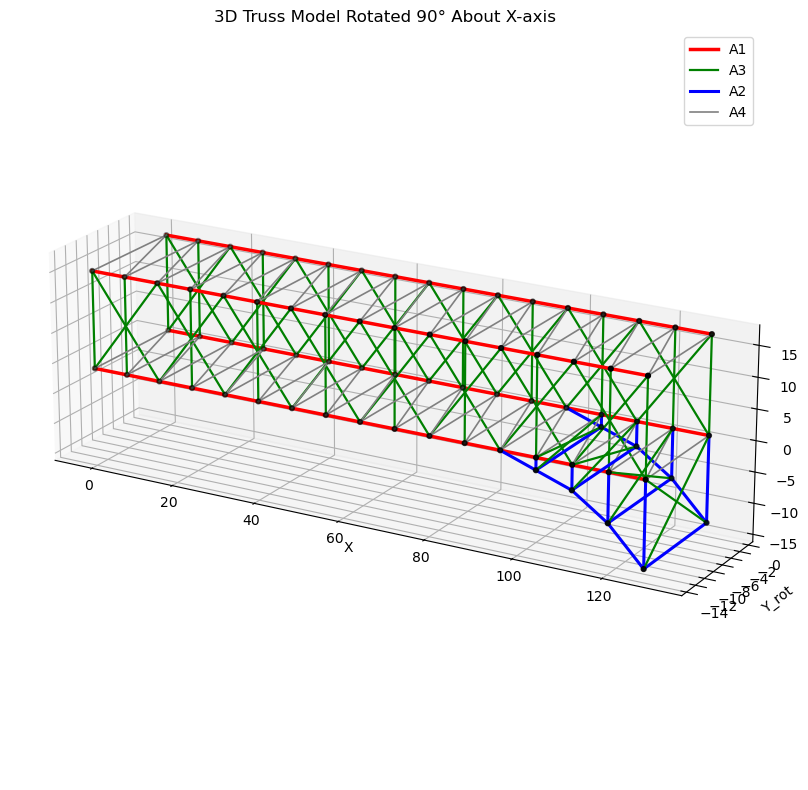

: 

: 

In [ ]:


# =========================
# 1. 读取结构数据
# =========================
with open(r"C:\Users\bchen601\Documents\GitHub\CEE6501_project_Boyang\inputs\final_structure.json", "r", encoding="utf-8") as f:
    data = json.load(f)

nodes = data["nodes"]
elements = data["elements"]

# =========================
# 2. 绕 x 轴旋转 90°
#    x' = x
#    y' = -z
#    z' = y
# =========================
def rotate_x_90(p):
    x, y, z = p
    return [x, -z, y]

# =========================
# 3. 颜色和线宽设置
# =========================
colors = {
    "A1": "red",    # main chords
    "A2": "blue",   # major web members
    "A3": "green",  # ordinary web members
    "A4": "gray"    # bracing / secondary members
}

linewidths = {
    "A1": 2.5,
    "A2": 2.2,
    "A3": 1.6,
    "A4": 1.2
}

# =========================
# 4. 创建 3D 图
# =========================
fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection="3d")

used_labels = set()

# =========================
# 5. 绘制杆件（使用旋转后的坐标）
# =========================
for e in elements.values():
    n1, n2, sec = e

    p1 = rotate_x_90(nodes[str(n1)])
    p2 = rotate_x_90(nodes[str(n2)])

    label = sec if sec not in used_labels else None
    used_labels.add(sec)

    ax.plot(
        [p1[0], p2[0]],
        [p1[1], p2[1]],
        [p1[2], p2[2]],
        color=colors.get(sec, "black"),
        linewidth=linewidths.get(sec, 1.0),
        label=label
    )

# =========================
# 6. 绘制节点（也使用旋转后的坐标）
# =========================
rot_nodes = [rotate_x_90(coord) for coord in nodes.values()]

xs = [p[0] for p in rot_nodes]
ys = [p[1] for p in rot_nodes]
zs = [p[2] for p in rot_nodes]

ax.scatter(xs, ys, zs, s=12, c="black")

# =========================
# 7. 坐标轴与标题
# =========================
ax.set_xlabel("X")
ax.set_ylabel("Y_rot")
ax.set_zlabel("Z_rot")
ax.set_title("3D Truss Model Rotated 90° About X-axis")

# =========================
# 8. 设置显示比例
#    旋转后原来的 y,z 互换了，所以比例也调整
# =========================
ax.set_box_aspect((128, 28, 40))

# =========================
# 9. 设置观察角度
# =========================
ax.view_init(elev=20, azim=-60)

# =========================
# 10. 图例
# =========================
ax.legend()

plt.tight_layout()
plt.show()